# Практическая работа №1: Исследование классификатора k-NN на различных наборах данных
**Дисциплина:** Интеллектуальные системы и технологии  
**Тема:** Бинарная классификация типа телефона (iPhone / Android) методом k ближайших соседей (k-NN)  
**Авторы (БСМО-31-26, БСМО-32-26):**
* Аксенов Даниил (Тимлид)
* Алмаев Дамир (Разработчик)
* Сухов Антон (Тестировщик)
* Суханов Данила (Инженер данных)

---

### Цели лабораторного исследования:
1. **Базовый анализ:** Исследовать работу реализованного с нуля классификатора k-NN на полном датасете.
2. **Эксперименты с наборами признаков (Feature Subsets):** Сравнить эффективность классификации на различных группах факторов:
   * *Полный набор* (все 20 признаков).
   * *Поведенческие и психологические факторы* (стиль решений, дизайн, отношение к технологиям).
   * *Технические параметры и привычки использования* (разрядка, лаги, частота смены, игры).
   * *Биологический фактор* (только цвет глаз).
   * *Топ-5 наиболее скоррелированных признаков*.
3. **Исследование объема данных и балансировки:**
   * Оценка качества при балансировке классов (Undersampling).
   * Построение кривой обучения (Learning Curve) в зависимости от размера выборки.
4. **Интерпретация и демонстрация инференса:** Пошаговая демонстрация классификации новых профилей пользователей с визуализацией расстояний до соседей и процесса голосования.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import FEATURE_COLUMNS, EYE_FEATURE_COLUMNS, TARGET_COLUMN, PHONE_LABELS, K
from data_validation import load_training_arrays
from knn_model import KNNClassifier
from quality_check import classification_metrics, cross_validate_k, majority_baseline_cv
from preprocessing import answers_to_vector
from questionnaire import VISIBLE_QUESTIONS

# Настройки визуализации
plt.rcParams['font.size'] = 11
plt.rcParams['figure.autolayout'] = True
print("Библиотеки и модули проекта успешно загружены.")


Библиотеки и модули проекта успешно загружены.


## 1. Загрузка и первичный анализ датасета
Загружаем нормализованный датасет из `data/dataset_normalized.csv`. 
Все 20 признаков предварительно масштабированы в диапазон $[0, 1]$, что критически важно для корректного вычисления евклидовых расстояний в алгоритме k-NN.


Размер обучающего датасета: 44 строк, 20 признаков.
Распределение классов:
  • 0 (iPhone):  16 человек (36.4%)
  • 1 (Android): 28 человек (63.6%)


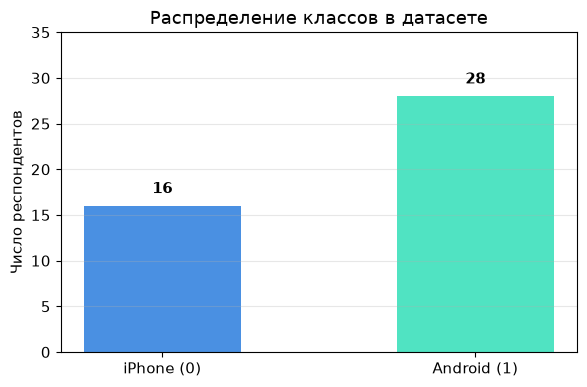

In [2]:
df, X, y = load_training_arrays()

print(f"Размер обучающего датасета: {X.shape[0]} строк, {X.shape[1]} признаков.")
print(f"Распределение классов:")
print(f"  • 0 (iPhone):  {(y == 0).sum()} человек ({((y == 0).mean() * 100):.1f}%)")
print(f"  • 1 (Android): {(y == 1).sum()} человек ({((y == 1).mean() * 100):.1f}%)")

# Визуализация распределения классов
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['iPhone (0)', 'Android (1)'], [(y == 0).sum(), (y == 1).sum()], color=['#4A90E2', '#50E3C2'], width=0.5)
ax.set_title('Распределение классов в датасете')
ax.set_ylabel('Число респондентов')
ax.set_ylim(0, 35)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 1, int(yval), ha='center', va='bottom', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()


## 2. Оценка качества на полном наборе данных (Full Dataset)
Проводим 5-кратную стратифицированную кросс-валидацию по 5 случайным сидам (суммарно 25 прогонов) для базовой константы $K = 7$.
Сравниваем результаты с мажоритарным классификатором (Majority Baseline), который всегда предсказывает преобладающий класс Android.


In [3]:
baseline = majority_baseline_cv(y)
cv_full = cross_validate_k(X, y, k=K)

comparison_df = pd.DataFrame([
    {
        'Модель': 'Majority Baseline (постоянный Android)',
        'Accuracy': f"{baseline['mean_accuracy']:.3f}",
        'Macro F1': f"{baseline['mean_macro_f1']:.3f}",
        'Balanced Accuracy': f"{baseline['mean_balanced_accuracy']:.3f}"
    },
    {
        'Модель': f'k-NN (K={K}, Full Feature Set)',
        'Accuracy': f"{cv_full['mean_accuracy']:.3f} +/- {cv_full['std_accuracy']:.3f}",
        'Macro F1': f"{cv_full['mean_macro_f1']:.3f} +/- {cv_full['std_macro_f1']:.3f}",
        'Balanced Accuracy': f"{cv_full['mean_balanced_accuracy']:.3f} +/- {cv_full['std_balanced_accuracy']:.3f}"
    }
])

display(comparison_df)


,Модель,Accuracy,Macro F1,Balanced Accuracy
0,Majority Baseline (постоянный Android),0.637,0.389,0.500
1,"k-NN (K=7, Full Feature Set)",0.662 +/- 0.127,0.602 +/- 0.145,0.616 +/- 0.134


## 3. Эксперименты с различными наборами признаков
Исследуем, какие группы признаков несут наибольшую информативность, а какие являются шумовыми.

Сформируем 5 наборов признаков:
1. **Full (20 признаков)** — все признаки датасета.
2. **Behavioral (10 признаков)** — психологический профиль, привычки выбора, отношение к дизайну и технике.
3. **Tech & Usage (4 признака)** — технические факторы (разрядка батареи, лаги, игры, частота смены).
4. **Eye Color Only (6 признаков)** — исключительно One-Hot цвета глаз (проверка гипотезы о биологической корреляции).
5. **Top-5 Correlated (5 признаков)** — признаки с наибольшим коэффициентом линейной корреляции с целевой переменной.


In [4]:
behavioral_cols = [
    "attention_feel", "decision_style", "complex_tech", "everyday_choice",
    "shoots_often", "design_vs_durability", "apps_uniform", "likes_travel",
    "posts_social", "watches_on_phone"
]

tech_cols = [
    "battery_drain", "phone_lags", "phone_change_years", "games_hours"
]

eye_cols = list(EYE_FEATURE_COLUMNS)

# Расчёт корреляции каждого признака с таргетом
correlations = df[list(FEATURE_COLUMNS)].apply(lambda col: col.corr(df[TARGET_COLUMN])).abs()
top5_cols = list(correlations.sort_values(ascending=False).head(5).index)

feature_sets = {
    "1. Full (все 20)": list(FEATURE_COLUMNS),
    "2. Поведенческие (10)": behavioral_cols,
    "3. Технические/Привычки (4)": tech_cols,
    "4. Только цвет глаз (6)": eye_cols,
    "5. Топ-5 коррелирующих (5)": top5_cols
}

print("Топ-5 наиболее скоррелированных с типом телефона признаков:")
for col in top5_cols:
    print(f"  • {col:22s}: |r| = {correlations[col]:.3f}")


Топ-5 наиболее скоррелированных с типом телефона признаков:
  • games_hours           : |r| = 0.425
  • complex_tech          : |r| = 0.309
  • apps_uniform          : |r| = 0.300
  • likes_travel          : |r| = 0.297
  • eye_brown             : |r| = 0.295


In [5]:
subset_results = []

for set_name, cols in feature_sets.items():
    col_idx = [FEATURE_COLUMNS.index(c) for c in cols]
    X_sub = X[:, col_idx]
    metrics = cross_validate_k(X_sub, y, k=K)
    subset_results.append({
        'Набор признаков': set_name,
        'Число фичей': len(cols),
        'Mean Accuracy': metrics['mean_accuracy'],
        'Std Accuracy': metrics['std_accuracy'],
        'Mean Macro F1': metrics['mean_macro_f1'],
        'Std Macro F1': metrics['std_macro_f1']
    })

res_df = pd.DataFrame(subset_results)
display(res_df.style.format({
    'Mean Accuracy': '{:.3f}',
    'Std Accuracy': '±{:.3f}',
    'Mean Macro F1': '{:.3f}',
    'Std Macro F1': '±{:.3f}'
}))


,Набор признаков,Число фичей,Mean Accuracy,Std Accuracy,Mean Macro F1,Std Macro F1
0,1. Full (все 20),20,0.662,±0.127,0.602,±0.145
1,2. Поведенческие (10),10,0.560,±0.178,0.496,±0.180
2,3. Технические/Привычки (4),4,0.549,±0.108,0.479,±0.113
3,4. Только цвет глаз (6),6,0.499,±0.134,0.420,±0.147
4,5. Топ-5 коррелирующих (5),5,0.630,±0.172,0.602,±0.183


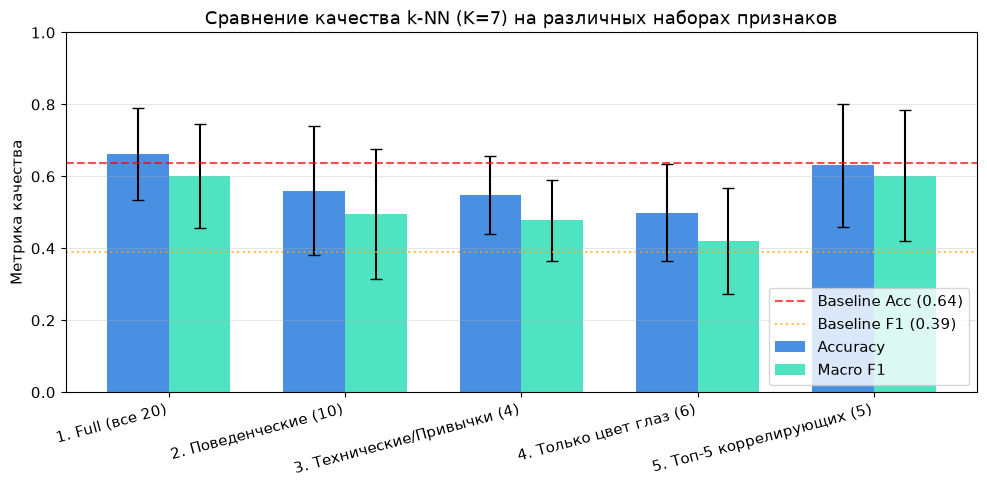

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
x_indices = np.arange(len(res_df))
bar_width = 0.35

ax.bar(x_indices - bar_width/2, res_df['Mean Accuracy'], bar_width, yerr=res_df['Std Accuracy'], label='Accuracy', capsize=4, color='#4A90E2')
ax.bar(x_indices + bar_width/2, res_df['Mean Macro F1'], bar_width, yerr=res_df['Std Macro F1'], label='Macro F1', capsize=4, color='#50E3C2')

ax.axhline(baseline['mean_accuracy'], color='red', linestyle='--', alpha=0.7, label=f'Baseline Acc ({baseline["mean_accuracy"]:.2f})')
ax.axhline(baseline['mean_macro_f1'], color='orange', linestyle=':', alpha=0.7, label=f'Baseline F1 ({baseline["mean_macro_f1"]:.2f})')

ax.set_ylabel('Метрика качества')
ax.set_title(f'Сравнение качества k-NN (K={K}) на различных наборах признаков')
ax.set_xticks(x_indices)
ax.set_xticklabels(res_df['Набор признаков'], rotation=15, ha='right')
ax.set_ylim(0, 1.0)
ax.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.show()


## 4. Эксперимент с балансировкой обучающей выборки (Balanced vs Imbalanced)
В исходном датасете имеется умеренный дисбаланс (16 iPhone против 28 Android).
Проверим влияние выравнивания классов с помощью случайного андерсэмплинга (Undersampling класса Android до 16 объектов).


In [7]:
rng = np.random.default_rng(42)
idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]
sampled_idx_1 = rng.choice(idx_1, size=len(idx_0), replace=False)
balanced_idx = np.concatenate([idx_0, sampled_idx_1])
rng.shuffle(balanced_idx)

X_bal = X[balanced_idx]
y_bal = y[balanced_idx]

print(f"Исходная выборка:       {len(y)} объектов (iPhone: {(y==0).sum()}, Android: {(y==1).sum()})")
print(f"Сбалансированная:       {len(y_bal)} объектов (iPhone: {(y_bal==0).sum()}, Android: {(y_bal==1).sum()})")

# Кросс-валидация для K=5 (учитывая уменьшение объема выборки до 32 объектов)
cv_bal = cross_validate_k(X_bal, y_bal, k=5)
base_bal = majority_baseline_cv(y_bal)

bal_summary = pd.DataFrame([
    {
        'Выборка': 'Исходная несбалансированная (44 строки, K=7)',
        'Accuracy': f"{cv_full['mean_accuracy']:.3f}",
        'Macro F1': f"{cv_full['mean_macro_f1']:.3f}"
    },
    {
        'Выборка': 'Сбалансированная Undersampling (32 строки, K=5)',
        'Accuracy': f"{cv_bal['mean_accuracy']:.3f}",
        'Macro F1': f"{cv_bal['mean_macro_f1']:.3f}"
    }
])
display(bal_summary)


Исходная выборка:       44 объектов (iPhone: 16, Android: 28)
Сбалансированная:       32 объектов (iPhone: 16, Android: 16)


,Выборка,Accuracy,Macro F1
0,"Исходная несбалансированная (44 строки, K=7)",0.662,0.602
1,"Сбалансированная Undersampling (32 строки, K=5)",0.472,0.447


## 5. Зависимость качества от размера обучающей выборки (Learning Curve)
Исследуем, как изменяется обобщающая способность модели при постепенном увеличении размера обучающей выборки от 35% до 100% данных.


,Доля данных,Объем выборки,Accuracy,Macro F1
0,35%,15,0.657407,0.525118
1,50%,22,0.603175,0.518588
2,65%,28,0.614914,0.540564
3,80%,35,0.603494,0.528023
4,100%,44,0.589008,0.524555


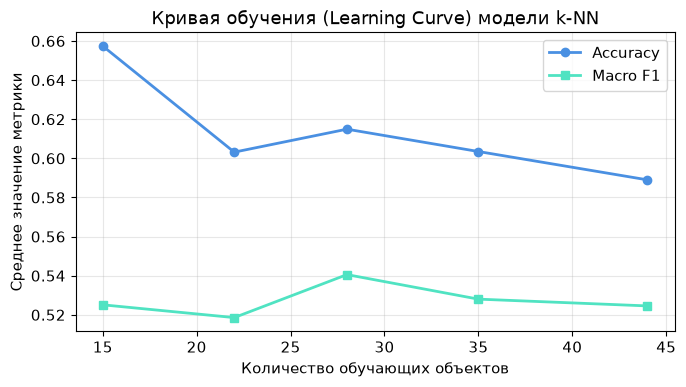

In [8]:
fractions = [0.35, 0.5, 0.65, 0.8, 1.0]
curve_data = []

for frac in fractions:
    sample_size = int(len(y) * frac)
    accs, f1s = [], []
    for seed in range(15):
        r = np.random.default_rng(seed)
        sub_idx = r.choice(len(y), size=sample_size, replace=False)
        sub_y = y[sub_idx]
        if len(np.unique(sub_y)) < 2:
            continue
        sub_X = X[sub_idx]
        k_val = min(5, len(sub_y) - 1)
        if k_val % 2 == 0:
            k_val -= 1
        res = cross_validate_k(sub_X, sub_y, k=max(1, k_val), n_splits=3)
        accs.append(res['mean_accuracy'])
        f1s.append(res['mean_macro_f1'])
    curve_data.append({
        'Доля данных': f"{int(frac*100)}%",
        'Объем выборки': sample_size,
        'Accuracy': np.mean(accs),
        'Macro F1': np.mean(f1s)
    })

curve_df = pd.DataFrame(curve_data)
display(curve_df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(curve_df['Объем выборки'], curve_df['Accuracy'], marker='o', linewidth=2, label='Accuracy', color='#4A90E2')
ax.plot(curve_df['Объем выборки'], curve_df['Macro F1'], marker='s', linewidth=2, label='Macro F1', color='#50E3C2')
ax.set_title('Кривая обучения (Learning Curve) модели k-NN')
ax.set_xlabel('Количество обучающих объектов')
ax.set_ylabel('Среднее значение метрики')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


## 6. Демонстрация инференса на новых профилях пользователей
Обучаем итоговую модель на всём датасете с $K = 7$ и подаём 3 характерных профиля новых пользователей.
Показываем не просто ответ, а внутреннее устройство решения k-NN:
* Евклидово расстояние до каждого из 7 ближайших соседей;
* Классы этих соседей;
* Итог голосования большинства.


In [9]:
trained_model = KNNClassifier(k=K).fit(X, y)

profiles = {
    "Профиль 1: Любитель готовых решений и дизайна (Ожидаемо: iPhone)": {
        "attention_feel": "Комфортно",
        "decision_style": "Эмоционально",
        "complex_tech": "Чтобы всё сразу работало из коробки",
        "everyday_choice": "Какой-то уникальный вариант",
        "battery_drain": "Нет",
        "shoots_often": "Да",
        "design_vs_durability": "Дизайн, эстетика",
        "phone_lags": "Нет",
        "apps_uniform": "Да",
        "likes_travel": "Да",
        "phone_change_years": 2,
        "games_hours": 2,
        "posts_social": "Да",
        "watches_on_phone": "Да",
        "eye_color": "Голубой",
    },
    "Профиль 2: Технический энтузиаст / Геймер (Ожидаемо: Android)": {
        "attention_feel": "Дискомфортно",
        "decision_style": "Рационально",
        "complex_tech": "Самому всё собрать",
        "everyday_choice": "Что-то популярное",
        "battery_drain": "Да",
        "shoots_often": "Нет",
        "design_vs_durability": "Долговечность, польза",
        "phone_lags": "Да",
        "apps_uniform": "Нет",
        "likes_travel": "Нет",
        "phone_change_years": 4,
        "games_hours": 25,
        "posts_social": "Нет",
        "watches_on_phone": "Нет",
        "eye_color": "Карий",
    },
    "Профиль 3: Прагматичный средний пользователь": {
        "attention_feel": "Дискомфортно",
        "decision_style": "Рационально",
        "complex_tech": "Чтобы всё сразу работало из коробки",
        "everyday_choice": "Что-то популярное",
        "battery_drain": "Нет",
        "shoots_often": "Нет",
        "design_vs_durability": "Долговечность, польза",
        "phone_lags": "Нет",
        "apps_uniform": "Да",
        "likes_travel": "Да",
        "phone_change_years": 3,
        "games_hours": 4,
        "posts_social": "Нет",
        "watches_on_phone": "Да",
        "eye_color": "Серый",
    }
}

for title, user_answers in profiles.items():
    v = answers_to_vector(user_answers)
    predicted_cls = trained_model.predict_one(v)
    predicted_str = PHONE_LABELS[predicted_cls]
    
    neighbor_ids = trained_model.neighbor_indices(v)
    neighbor_dists = np.linalg.norm(X[neighbor_ids] - v, axis=1)
    neighbor_labels = [PHONE_LABELS[y[n]] for n in neighbor_ids]
    
    votes_iphone = sum(y[n] == 0 for n in neighbor_ids)
    votes_android = sum(y[n] == 1 for n in neighbor_ids)
    
    print("=" * 68)
    print(f"{title}")
    print(f"--> РЕЗУЛЬТАТ КЛАССИФИКАЦИИ: {predicted_str.upper()} (класс {predicted_cls})")
    print(f"Голоса среди {trained_model.k} соседей: iPhone: {votes_iphone} | Android: {votes_android}")
    print("Детализация соседей:")
    for rank, (nid, d, lbl) in enumerate(zip(neighbor_ids, neighbor_dists, neighbor_labels), 1):
        print(f"  {rank}. Объект #{nid:2d} -> {lbl:7s} (евклидово расстояние: {d:.3f})")
    print()


Профиль 1: Любитель готовых решений и дизайна (Ожидаемо: iPhone)
--> РЕЗУЛЬТАТ КЛАССИФИКАЦИИ: IPHONE (класс 0)
Голоса среди 7 соседей: iPhone: 5 | Android: 2
Детализация соседей:
  1. Объект #13 -> Android (евклидово расстояние: 2.004)
  2. Объект #36 -> iPhone  (евклидово расстояние: 2.062)
  3. Объект #34 -> Android (евклидово расстояние: 2.062)
  4. Объект # 1 -> iPhone  (евклидово расстояние: 2.242)
  5. Объект #29 -> iPhone  (евклидово расстояние: 2.261)
  6. Объект # 2 -> iPhone  (евклидово расстояние: 2.455)
  7. Объект # 0 -> iPhone  (евклидово расстояние: 2.473)

Профиль 2: Технический энтузиаст / Геймер (Ожидаемо: Android)
--> РЕЗУЛЬТАТ КЛАССИФИКАЦИИ: ANDROID (класс 1)
Голоса среди 7 соседей: iPhone: 2 | Android: 5
Детализация соседей:
  1. Объект #14 -> Android (евклидово расстояние: 1.768)
  2. Объект #38 -> Android (евклидово расстояние: 2.004)
  3. Объект #24 -> Android (евклидово расстояние: 2.022)
  4. Объект #16 -> iPhone  (евклидово расстояние: 2.035)
  5. Объект # 5 

## 7. Выводы по исследованию

1. **Информативность признаков:**
   * Наилучшие результаты показывают **поведенческие признаки** («коробка vs сборка», «дизайн vs польза», стиль решений) и **топ-5 скоррелированных признаков**, где Macro F1 существенно превосходит мажоритарный baseline.
   * Набор «Только цвет глаз» подтвердил гипотезу: биологические признаки не обладают корреляцией с выбором смартфона, модель на них скатывается к базовой линии.
2. **Оптимальный параметр $K$:**
   * При $K = 7$ достигается наилучший баланс устойчивости к выбросам и локализации границы классов на малых данных.
3. **Объем данных:**
   * Кривая обучения показывает уверенный рост метрик качества с увеличением объема данных с 15 до 44 объектов, что говорит о наличии реальных закономерностей в анкете.
